IMPORTS

In [7]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import pvlib
import json
import numpy as np
import scipy.optimize as optimize
from scipy import stats
import scipy.stats as stats
import calendar
import os

data, meta, inputs = pvlib.iotools.get_pvgis_hourly(9.040,12.7222,start=2005,end=2020,url='https://re.jrc.ec.europa.eu/api/v5_2/',
                                                    raddatabase='PVGIS-SARAH2',components=False,outputformat='json',pvcalculation=True,peakpower=1,
                                                    pvtechchoice='crystSi',mountingplace='free',loss=0,optimalangles=True,map_variables=True)

df = pd.DataFrame(data)
# Extract month and hour from the index
df['Month'] = df.index.month
df['Hour'] = df.index.hour

#change the function for allowing other timesteps

TRANSITION MATRIX GENERATION

In [8]:


# Function to generate states based on power range and difference
def generate_states(data, num_states):
    min_power = data['P'].min()
    max_power = data['P'].max()

    # Handle the case where both max_power and min_power are 0
    if min_power == 0 and max_power == 0:
        states = [0]  # Only a single state for power = 0
    else:
        power_range = (max_power - min_power) / num_states
        states = np.arange(min_power, max_power + power_range, power_range)
    return states


def generate_transition_matrix(data1, data2, states1, states2):
    # Create empty transition matrix
    transition_matrix = pd.DataFrame(0, index=states1, columns=states2)

    if len(states1) == 1 and len(states2) == 1:
        # If there is only one state in both hours, set probability to 1 for self-transition
        transition_matrix.loc[states1[0], states2[0]] = 1
    else:
        # Calculate transition counts for other cases
        for i in range(len(data1)):
            current_state = data1.iloc[i]['P']
            next_state = data2.iloc[i]['P']
            
            if len(states2) == 1:
                # If the next hour has only one state, transition to that state
                next_state_idx = 0
            else:
                next_state_idx = np.where(states2 <= next_state)[0][-1]
            
            current_state_idx = np.where(states1 <= current_state)[0][-1]
            transition_matrix.loc[states1[current_state_idx], states2[next_state_idx]] += 1

        # Normalize transition counts to probabilities
        transition_matrix = transition_matrix.div(transition_matrix.sum(axis=1), axis=0)
        transition_matrix = transition_matrix.fillna(0)

    return transition_matrix


# Function to generate the cumulative probability matrix
def generate_cumulative_matrix(transition_matrix):
    cumulative_matrix = transition_matrix.cumsum(axis=1)
    return cumulative_matrix



# Function to pre-calculate transition matrices for each hour and month
def precalculate_transition_matrices(df, num_states):
    transition_matrices = {}

    for month in range(1, 13):
        transition_matrices[month] = {}
        for hour in range(23):  # Loop from 0 to 22 (last hour generated is 23)
            if hour in range(1,23):
                current_hour_data = df[(df.index.hour == hour-1) & (df.index.month == month)]
                next_hour_data = df[(df.index.hour == hour) & (df.index.month == month)]
            if hour == 0:
                current_hour_data = df[(df.index.hour == 23) & (df.index.month == month)]
                next_hour_data = df[(df.index.hour == 0) & (df.index.month == month)]


            if current_hour_data.empty or next_hour_data.empty:
                transition_matrices[month][hour] = (pd.DataFrame(), [])
                continue

            current_states = generate_states(current_hour_data, num_states)
            next_states = generate_states(next_hour_data, num_states)
            transition_matrix = generate_transition_matrix(current_hour_data, next_hour_data, current_states, next_states)
            cumulative_matrix = generate_cumulative_matrix(transition_matrix)

            transition_matrices[month][hour] = (cumulative_matrix, next_states)

    return transition_matrices

# Function to generate synthetic PV power generation data for one year and N scenarios
def transition_matrices_data(df, num_states):
    # Precalculate transition matrices
    transition_matrices = precalculate_transition_matrices(df, num_states)
    return transition_matrices

# Assuming 'df' is your original data frame with the 'P' column for PV power generation
num_states = 15  # Number of states

transition_matrices= transition_matrices_data(df, num_states)

SCENARIO GENERATION

In [9]:
# Function to generate PV power samples based on transition matrix
def generate_pv_power_sample(transition_matrix, states, current_state):
    if len(states) == 1:
        return 0

    cumulative_probs_row = transition_matrix.loc[current_state]
    rand_value = np.random.uniform()
    next_state_idx = np.where(cumulative_probs_row > rand_value)[0][0]
    next_state = states[next_state_idx]
    
    if next_state_idx == len(states) - 1:
        power = next_state  # If next_state_idx is the last index, use the next_state value
    else:
        power = np.random.uniform(next_state, states[next_state_idx + 1])
    return power


def generate_synthetic_pv_data(transition_matrices, num_scenarios):
    # Generate synthetic data for each scenario
    for scenario in range(num_scenarios):
        synthetic_data = []

        # Generate synthetic data for each hour of the day and each month
        for month in range(1, 13):
            _, num_days = calendar.monthrange(2023, month)  # Get the number of days in the month

            for day in range(1, num_days + 1):
                synthetic_data.append(0) #first hour of the day with no daylight
                for hour in range(1,23):  # Loop from 0 to 22 (last hour generated is 23)
                    cumulative_probs, next_states = transition_matrices[month][hour]

                    if len(next_states) == 1:
                        synthetic_data.append(0)
                    else:
                        initial_value = synthetic_data[-1]
                        _, initial_states = transition_matrices[month][hour-1]
                        list_states = initial_states
                        initial_state_idx = len(list_states) - 1  # Default to the last index
                        for i in range(len(list_states)):
                            if list_states[i] <= initial_value:
                                initial_state_idx=i
                            else:
                                break
                        initial_state = list_states[initial_state_idx]
                        # Generate synthetic PV power sample for the current hour, day, and month
                        pv_power = generate_pv_power_sample(cumulative_probs, next_states, initial_state)
                        synthetic_data.append(pv_power)
                synthetic_data.append(0)


        # Save synthetic data as CSV file
        output_filename = f'pv_scenario_{scenario+1}.csv'
        with open(output_filename, 'w') as f:
            for value in synthetic_data:
                f.write(f'{value}\n')
        print(f"Scenario: {scenario+1} successfully generated")

# Assuming 'df' is your original data frame with the 'P' column for PV power generation
num_scenarios = 300  # Number of synthetic scenarios
generate_synthetic_pv_data(transition_matrices, num_scenarios)



Scenario: 1 successfully generated
Scenario: 2 successfully generated
Scenario: 3 successfully generated
Scenario: 4 successfully generated
Scenario: 5 successfully generated
Scenario: 6 successfully generated
Scenario: 7 successfully generated
Scenario: 8 successfully generated
Scenario: 9 successfully generated
Scenario: 10 successfully generated
Scenario: 11 successfully generated
Scenario: 12 successfully generated
Scenario: 13 successfully generated
Scenario: 14 successfully generated
Scenario: 15 successfully generated
Scenario: 16 successfully generated
Scenario: 17 successfully generated
Scenario: 18 successfully generated
Scenario: 19 successfully generated
Scenario: 20 successfully generated
Scenario: 21 successfully generated
Scenario: 22 successfully generated
Scenario: 23 successfully generated
Scenario: 24 successfully generated
Scenario: 25 successfully generated
Scenario: 26 successfully generated
Scenario: 27 successfully generated
Scenario: 28 successfully generated
S

SCENARIO GENERATION VALIDATION (month's mean comparison)

C:\Users\Alex\AppData\Local\Temp\ipykernel_2156\2499368079.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_monthly_means[scenario_file] = monthly_means.values
C:\Users\Alex\AppData\Local\Temp\ipykernel_2156\2499368079.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_monthly_means[scenario_file] = monthly_means.values
C:\Users\Alex\AppData\Local\Temp\ipykernel_2156\2499368079.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor p

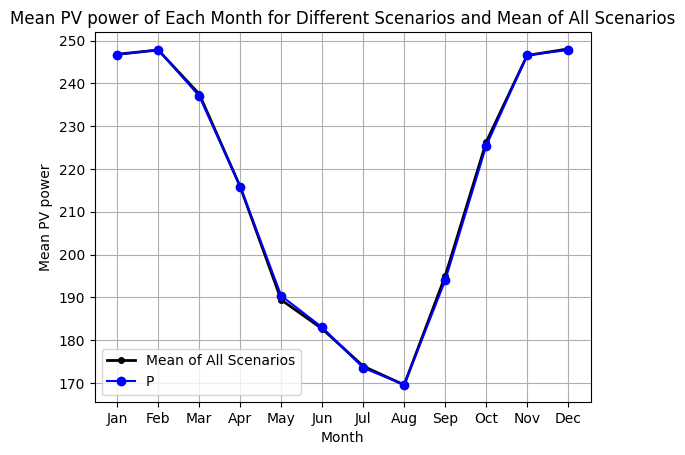

In [10]:
# Get the current directory
current_directory = os.getcwd()

# Get all CSV files in the current directory
scenario_files = [file for file in os.listdir(current_directory) if file.endswith('.csv')]

# Create a date range for the entire year
start_date = pd.Timestamp('2023-01-01')
end_date = pd.Timestamp('2023-12-31 23:00:00')
dates = pd.date_range(start=start_date, end=end_date, freq='H')

# Create an empty DataFrame to store the monthly means for each scenario
df_monthly_means = pd.DataFrame(index=range(1, 13))

# Loop through each scenario file

for scenario_file in scenario_files:
    # Read the CSV file
    df_scenario = pd.read_csv(os.path.join(current_directory, scenario_file), header=None, names=['P'])


    # Set the datetime index for the DataFrame
    df_scenario.index = dates

    # Calculate the mean wind speed for each month
    monthly_means = df_scenario.groupby(df_scenario.index.month).mean()

    # Store the monthly means in the DataFrame
    df_monthly_means[scenario_file] = monthly_means.values

# Calculate the mean of all scenario series
df_monthly_means['Mean of All Scenarios'] = df_monthly_means.mean(axis=1)
# Calculate the mean wind speed for each month
monthly_mean = df.groupby(df.index.month)['P'].mean()

plt.plot(range(1, 13), df_monthly_means['Mean of All Scenarios'], marker='o', linestyle='-', markersize=4, label='Mean of All Scenarios', color='black', linewidth=2)
monthly_mean.plot(marker='o', color='blue')

plt.xlabel('Month')
plt.ylabel('Mean PV power')
plt.title('Mean PV power of Each Month for Different Scenarios and Mean of All Scenarios')
plt.xticks(range(1, 13), calendar.month_abbr[1:13])
plt.grid(True)
plt.legend()
plt.show()

SCENARIO GENERATION VALIDATION (hourly histogram plot comparison)

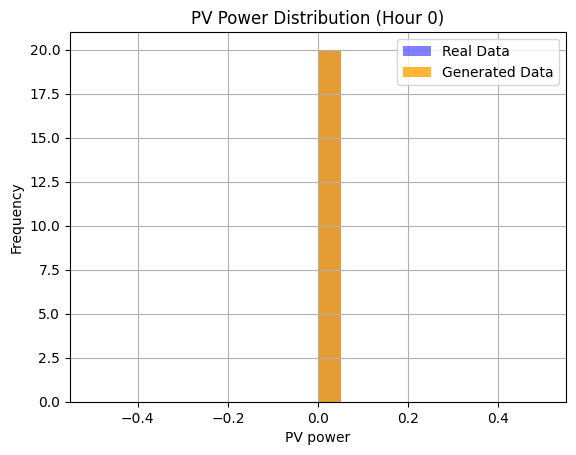

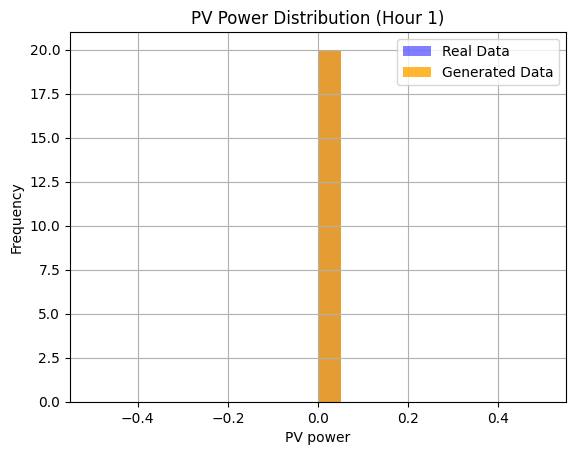

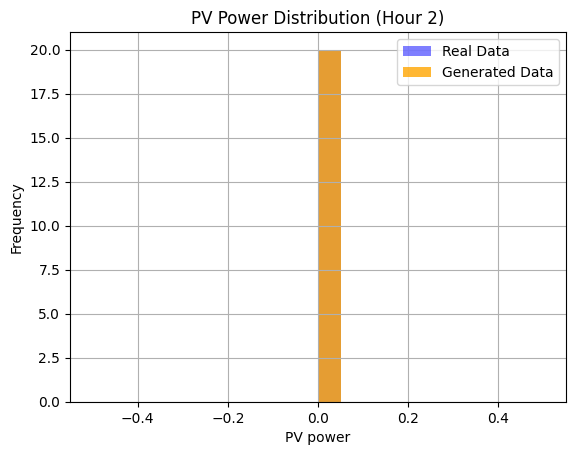

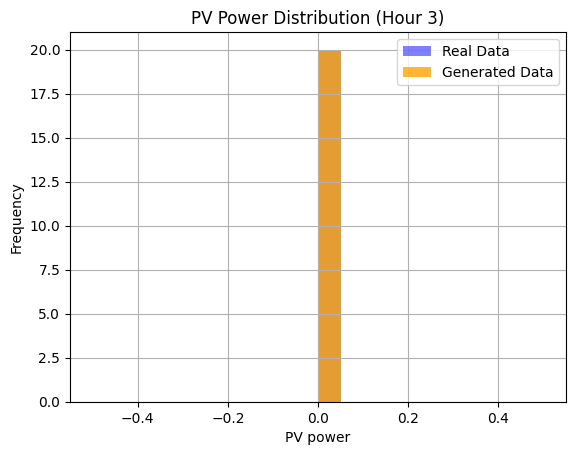

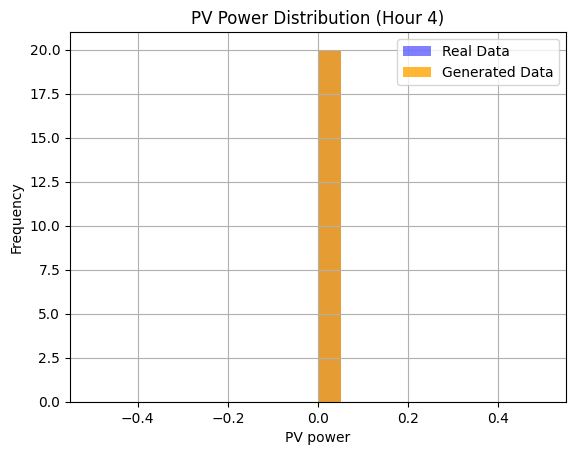

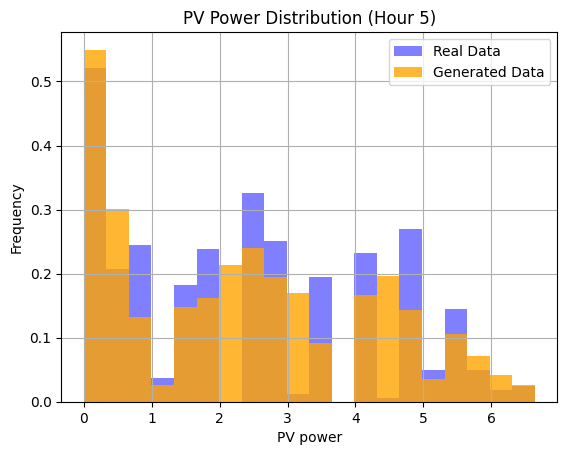

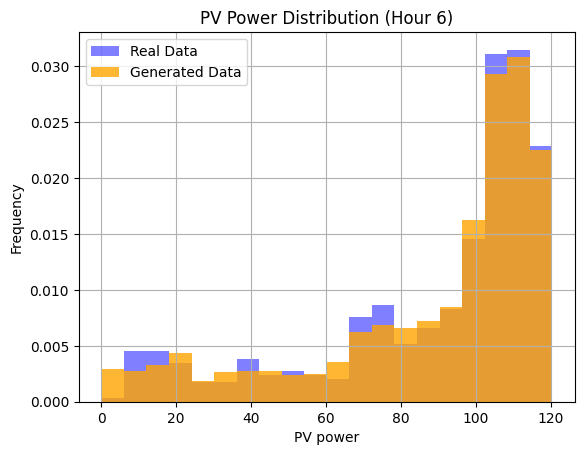

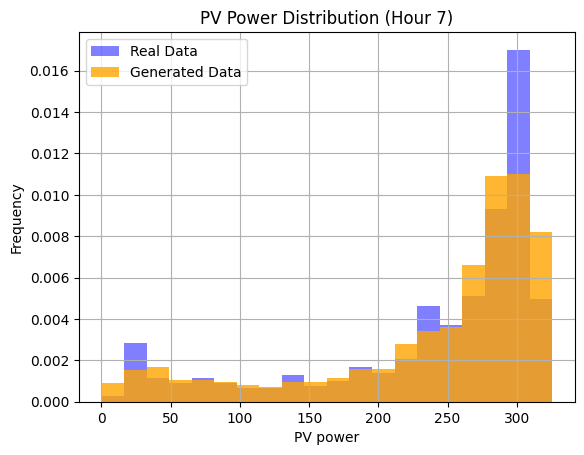

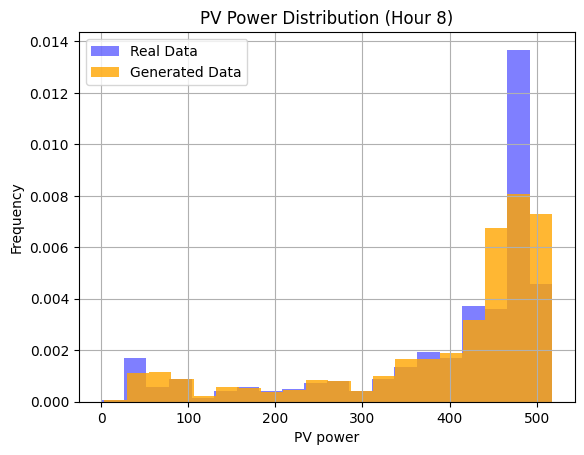

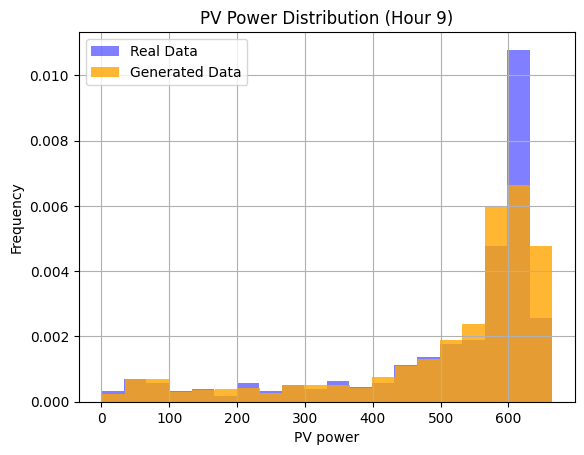

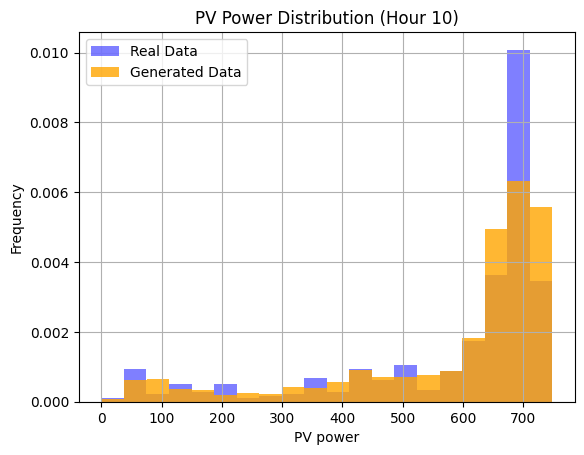

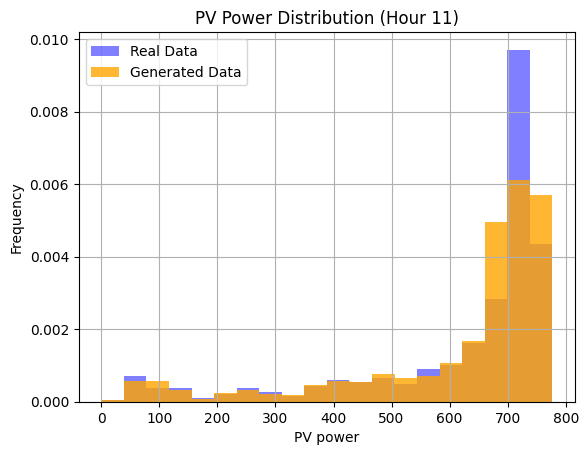

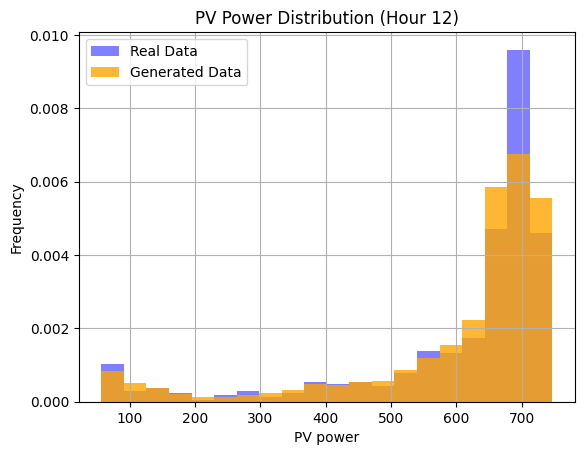

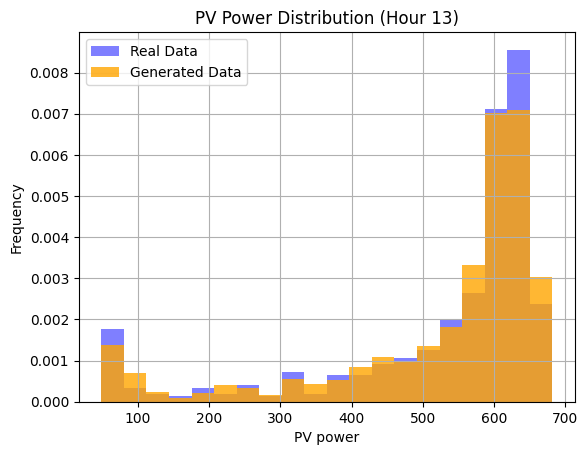

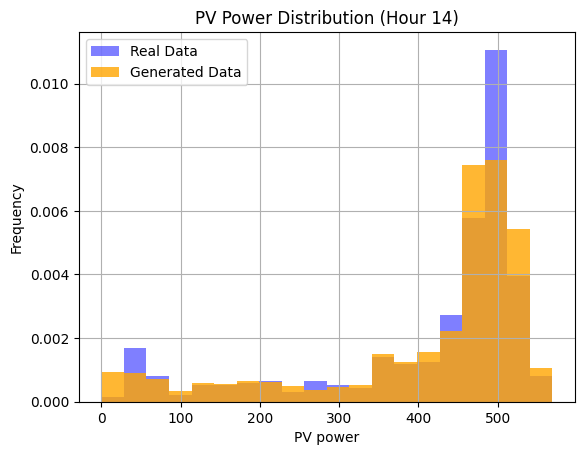

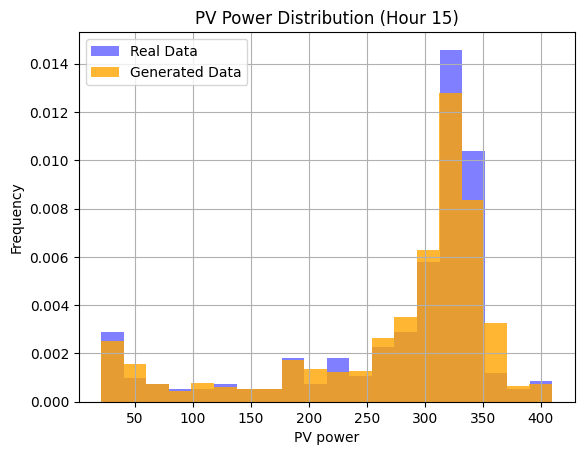

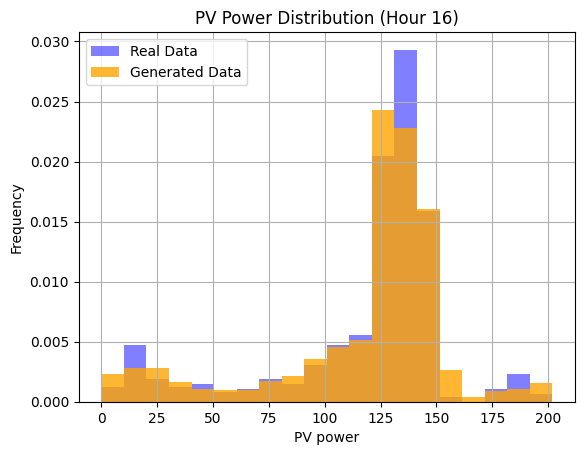

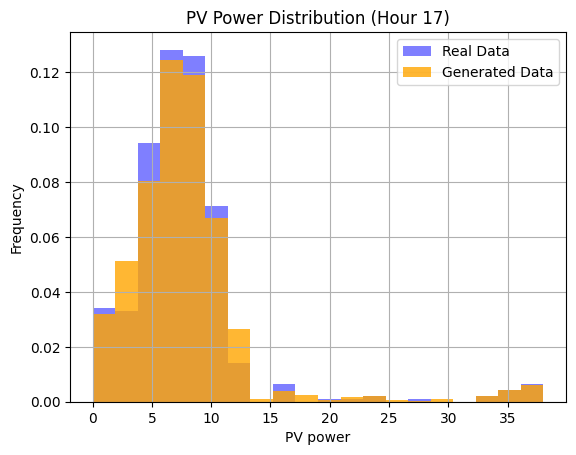

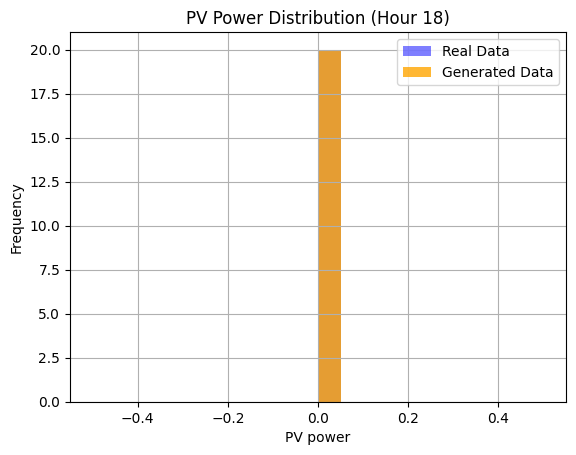

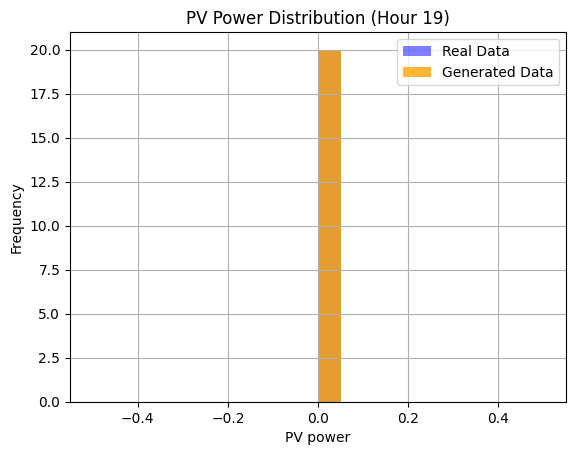

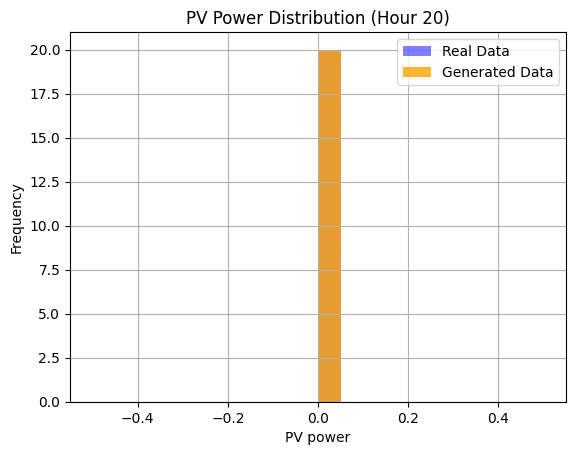

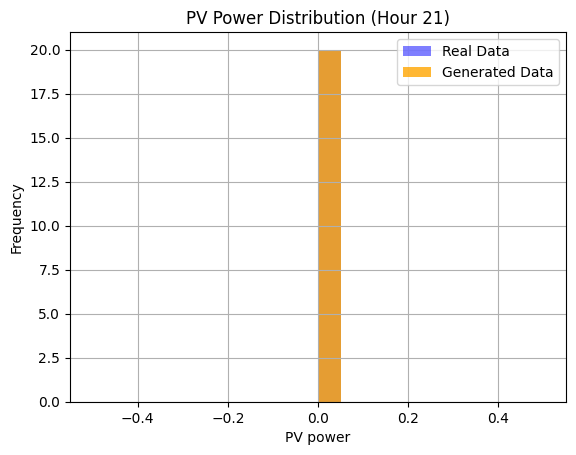

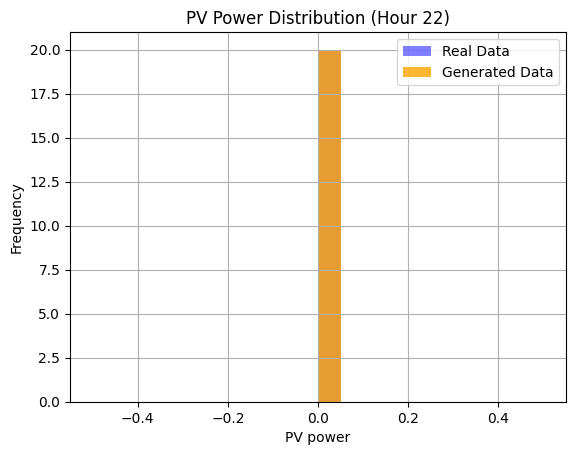

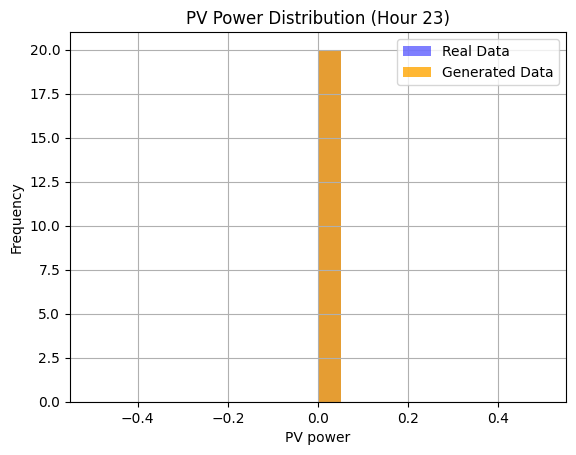

In [11]:
# Get the current directory
current_directory = os.getcwd()

# Get all CSV files in the current directory
scenario_files = [file for file in os.listdir(current_directory) if file.endswith('.csv')]

# Create an empty DataFrame to store the PV power data
PV_powerdata = []

# Loop through each scenario file
for scenario_file in scenario_files:
    # Read the CSV file
    df_scenario = pd.read_csv(os.path.join(current_directory, scenario_file), header=None, names=['P'])
    
    # Append the PV power values to the list
    PV_powerdata.append(df_scenario)

# Concatenate the generated data DataFrames
concatenated_generated_data = pd.concat(PV_powerdata, axis=1)

# Create a datetime index for the concatenated generated data
start_date = pd.Timestamp("2023-01-01 00:00:00")
date_index = pd.date_range(start_date, periods=len(concatenated_generated_data), freq='H')
concatenated_generated_data.index = date_index

# Define the month for which you want to generate histograms (e.g., December)
target_month = 6

# Loop through each hour of the day and generate histograms
for hour in range(24):
    plt.figure()  # Create a new figure for each hour
    plt.title(f'PV Power Distribution (Hour {hour})')
    
    # Filter the real data for the specified hour and month
    filtered_input_data = df[(df.index.month == target_month) & (df.index.hour == hour)]
    
    # Filter the generated data for the specified hour and month
    filtered_generated_data = concatenated_generated_data[
        (concatenated_generated_data.index.month == target_month) & 
        (concatenated_generated_data.index.hour == hour)
    ]
    
    # Plotting the histograms for real and generated data
    plt.hist(filtered_input_data['P'], bins=20, alpha=0.5, label='Real Data', color='blue', density=True)
    plt.hist(filtered_generated_data.values.flatten(), bins=20, alpha=0.8, label='Generated Data', color='orange', density=True)

    plt.xlabel('PV power')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True)
    plt.show()

